In [106]:
import os
import pandas as pd
import re

# 设置文件目录
directory = './grid_search_new'

# 定义存储结果的列表
data = []

# 获取所有以throughput_general_nested_booking_limit_limit_开头的文件
for filename in os.listdir(directory):
    if filename.startswith('throughput_general_nested_booking_limit_limit_') and filename.endswith('.csv'):
        # 使用正则表达式提取qps和rates
        match = re.match(r'throughput_general_nested_booking_limit_limit_\d+_qps=(\d+)_rates=_([\d_]+)_batch_size_\d+\.csv', filename)
        if match:
            qps = int(match.group(1))  # 提取qps并转换为整数
            rates = match.group(2)  # 提取rates作为字符串
            file_path = os.path.join(directory, filename)  # 获取文件路径
            data.append([file_path, qps, rates])

# 将数据转换为DataFrame
df1 = pd.DataFrame(data, columns=['file_path_nested', 'qps_nested', 'rates_nested'])

#print(df1)

In [107]:
directory = './sarathi_match_grid_search'

# 定义存储结果的列表
data = []

# 获取所有以throughput_general_nested_booking_limit_limit_开头的文件
for filename in os.listdir(directory):
    if filename.startswith('throughput_') :
        # 使用正则表达式提取qps和rates
        match = re.match(r'throughput_sarathi_batch_size_\d+_qps=(\d+)\.csv', filename)
        if match:
            qps = int(match.group(1))  # 提取qps并转换为整数
            file_path = os.path.join(directory, filename)  # 获取文件路径
            data.append([file_path, qps])

# 将数据转换为DataFrame
df2 = pd.DataFrame(data, columns=['file_path_sarathi', 'qps_sarathi'])

In [108]:
import pandas as pd

# 假设 df1 和 df2 已经定义
df3 = pd.merge(df1, df2, left_on='qps_nested', right_on='qps_sarathi', how='inner')

# 选择需要的列，假设你需要保留所有来自 df1 和 df2 的列
df3 = df3[['file_path_nested', 'file_path_sarathi','rates_nested', 'qps_sarathi', 'qps_nested']]

In [109]:
df3

,file_path_nested,file_path_sarathi,rates_nested,qps_sarathi,qps_nested
0,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_8_4_1,109,109
1,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,32_8_4_2_1,47,47
2,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,16_8_4_2_1,31,31
3,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_4_2,230,230
4,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_16_8_2,122,122
5,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_16_8,248,248
6,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_2_1,227,227
7,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_32_16_8_1,121,121
8,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,64_16_8_2_1,91,91
9,./grid_search_new/throughput_general_nested_bo...,./sarathi_match_grid_search/throughput_sarathi...,128_64_32_16_1,241,241


In [110]:
import pandas as pd
import numpy as np

# 假设 df3 已经定义并加载

# 设置 t0 和 t1
t0 = 142
t1 = 150

# 遍历 df3 的每一行
for idx, row in df3.iterrows():
    # 读取两个 CSV 文件
    df_nested = pd.read_csv(row['file_path_nested'])
    df_sarathi = pd.read_csv(row['file_path_sarathi'])
    
    # 提取 'Time (sec)' 和 'throughput' 列
    time_nested = df_nested['Time (sec)']
    throughput_nested = df_nested['throughput']
    
    time_sarathi = df_sarathi['Time (sec)']
    throughput_sarathi = df_sarathi['throughput']
    
    # 计算 t 时刻的 throughput/t 的值
    throughput_nested_t = throughput_nested / time_nested
    throughput_sarathi_t = throughput_sarathi / time_sarathi
    
    # 从 t0 到 t1 的均值
    # 选取时间范围 [t0, t1] 内的行
    nested_range = (time_nested >= t0) & (time_nested <= t1)
    sarathi_range = (time_sarathi >= t0) & (time_sarathi <= t1)
    
    mean_avg_throughput_nested = np.mean(throughput_nested_t[nested_range])
    mean_avg_throughput_sarathi = np.mean(throughput_sarathi_t[sarathi_range])
    
    # 将计算结果加入原来的 df3 行
    df3.at[idx, 'mean_avg_throughput_nested'] = mean_avg_throughput_nested
    df3.at[idx, 'mean_avg_throughput_sarathi'] = mean_avg_throughput_sarathi
    
    # 计算 gap
    gap = mean_avg_throughput_sarathi - mean_avg_throughput_nested
    df3.at[idx, 'gap'] = gap

# 按照 qps_sarathi 列进行排序
df3 = df3.sort_values(by='qps_sarathi').reset_index(drop=True)

# 删除不需要的列
df3 = df3.drop(columns=['file_path_nested', 'file_path_sarathi'])

df3


,rates_nested,qps_sarathi,qps_nested,mean_avg_throughput_nested,mean_avg_throughput_sarathi,gap
0,16_8_4_2_1,31,31,4128.842853,4667.239908,538.397056
1,32_8_4_2_1,47,47,5586.368470,6133.323642,546.955172
2,32_16_4_2_1,55,55,5783.490578,6154.680161,371.189583
3,32_16_8_2_1,59,59,5816.959878,6159.681274,342.721395
4,32_16_8_4_1,61,61,5830.053635,6162.899737,332.846102
5,32_16_8_4_2,62,62,5845.964403,6158.391717,312.427315
6,64_8_4_2_1,79,79,5551.290700,6167.408066,616.117366
7,64_16_4_2_1,87,87,5675.199316,6173.311771,498.112455
8,64_16_8_2_1,91,91,5728.665601,6171.032040,442.366439
9,64_16_8_4_1,93,93,5749.788539,6172.209077,422.420538


In [9]:
import pandas as pd

nested1 = pd.read_csv("./nested_archer/throughput_general_nested_booking_limit_limit_132_qps=32_rates=_16_8_4_4_batch_size_128.csv")
nested2 = pd.read_csv("./nested_archer/throughput_general_nested_booking_limit_limit_130_qps=128_rates=_64_32_16_16_batch_size_127.csv")

sarathi1 = pd.read_csv("./sarathi_archer/throughput_sarathi_batch_size_128_qps=32.csv")
sarathi2 = pd.read_csv("./sarathi_archer/throughput_sarathi_batch_size_128_qps=128.csv")

dfs = [nested1, nested2, sarathi1, sarathi2]
for df in dfs:
    df["throughput/t"] = df["throughput"] / df["Time (sec)"]

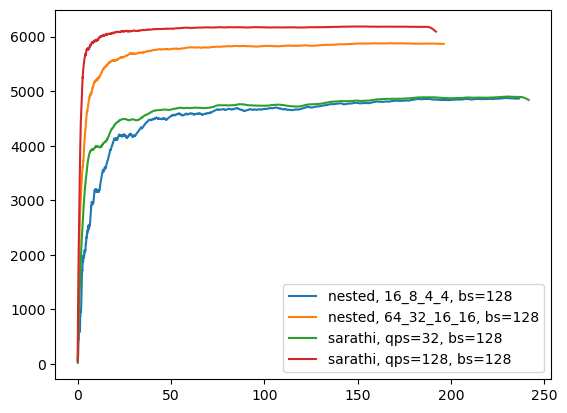

In [10]:
import matplotlib.pyplot as plt

plt.plot(nested1["Time (sec)"], nested1["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(nested2["Time (sec)"], nested2["throughput/t"], label="nested, 64_32_16_16, bs=128")
plt.plot(sarathi1["Time (sec)"], sarathi1["throughput/t"], label="sarathi, qps=32, bs=128")
plt.plot(sarathi2["Time (sec)"], sarathi2["throughput/t"], label="sarathi, qps=128, bs=128")
plt.legend()
plt.show()

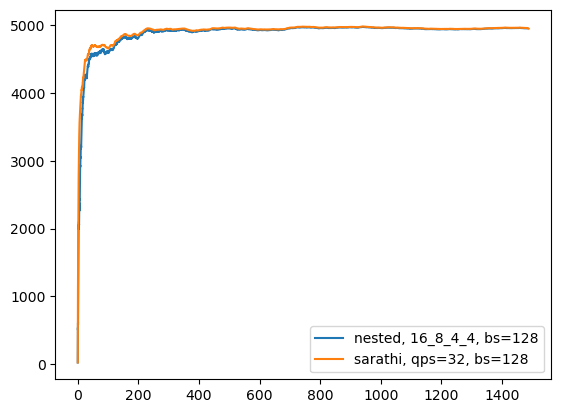

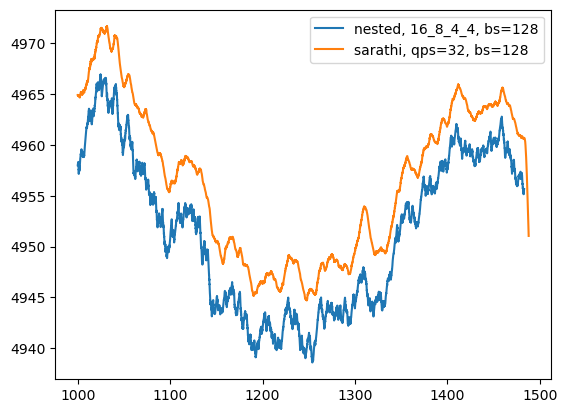

In [21]:
import pandas as pd

nested11 = pd.read_csv("./4e5_reqs/throughput_general_nested_booking_limit_limit_129_qps=32_rates=_16_8_4_4_batch_size_127.csv")


sarathi11 = pd.read_csv("./4e5_reqs/throughput_sarathi_batch_size_128_qps=32.csv")

dfs = [nested11,sarathi11]
for df in dfs:
    df["throughput/t"] = df["throughput"] / df["Time (sec)"]

import matplotlib.pyplot as plt

plt.plot(nested11["Time (sec)"], nested11["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(sarathi11["Time (sec)"], sarathi11["throughput/t"], label="sarathi, qps=32, bs=128")
plt.legend()
plt.show()

# 过滤 Time (sec) > 1000 的数据
nested11_filtered = nested11[nested11["Time (sec)"] > 1000]
sarathi11_filtered = sarathi11[sarathi11["Time (sec)"] > 1000]

plt.plot(nested11_filtered["Time (sec)"], nested11_filtered["throughput/t"], label="nested, 16_8_4_4, bs=128")
plt.plot(sarathi11_filtered["Time (sec)"], sarathi11_filtered["throughput/t"], label="sarathi, qps=32, bs=128")
plt.legend()
plt.show()

# import matplotlib.pyplot as plt

# a = 2000

# nested11 = nested11[a:]
# sarathi11 = sarathi11[a:]

# plt.plot(nested11["Time (sec)"], nested11["throughput/t"], label="nested, 16_8_4_4, bs=128")
# plt.plot(sarathi11["Time (sec)"], sarathi11["throughput/t"], label="sarathi, qps=32, bs=128")
# plt.legend()
# plt.show()